<center>Tabela Comparativa de Todos os Modelos Avalliados</center>

|             Algoritmo                |    AUC-ROC    |  F1-Score(Churn)   | Recall (Sensibilidade) | Precisão (Churn) |
| ------------------------------------ | ------------- | ------------------ | -----------------------| ---------------- |
|Regressão Logística (Limiar Otimizado)|    0,6274     |     0,5540         |         78,79%         |      42,72%      |
|Random Forest Otimizado               |    0,6257     |     0,5397         |         72,73%         |      42,91%      |
|Regressão Logística Base              |    0,6274     |     0,5409         |         72,12%         |      43,27%      |
|XGBoost Classifier                    |    0,6171     |     0,5328         |         68,89%         |      43,44%      |

<hr>

#### Escolha do Modelo Campeão para Interpretação com SHAP

O modelo campeão recomendado para a etapa de interpretação é a <b>Regressão Logística Otimizada</b> (ou, alternativamente, o <b>Random Forest Orimizado</b> caso deseje demonstrar a explicabilidade de um algoritmo baseado em árvores e relações não-lineares):

1. Campeão por Métricas de Negócio (Regressão Logística Otimizada):
   
   * <b>Maior Recall(78,79%)</b>: Captura 390 dos 495 cancelamentos reais no lote de teste.
   * <b>Maior F1-Score(55,40%)</b>: Melhor equilíbrio harmônico para a classe crítica (Churn = 1).
   * <b>Maior AUC-ROC(62,74%)</b>: Maior capacidade de ordenação de risco entre todos os modelos.
<br>
2. Campeão para Algoritimos de Árvore (Random Forest Otimizado):

   * O Random Forest Otimizado teve o segundo melhor desempenho geral (AUC-roc de 62,57% e Recall 72,73%). É a escolha ideal para demonstrar o uso so shap.TreeExplainer em modelos não lineares mais complexos.

<hr>

In [1]:
# Importando os pacotes das bibliotecas
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

Modelo Random Forest Otimizado e dados carregados com sucesso!


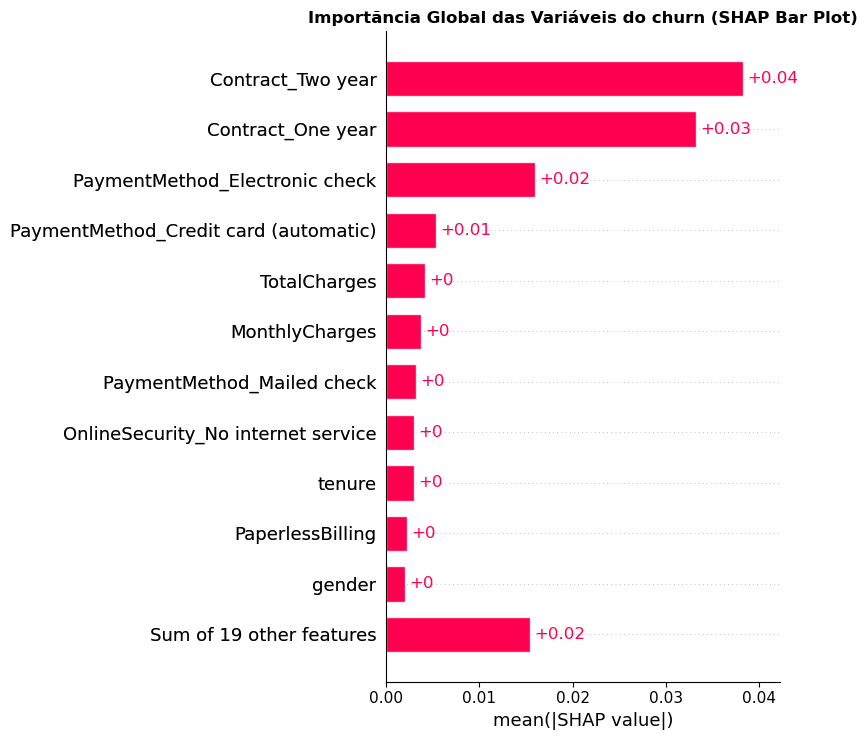

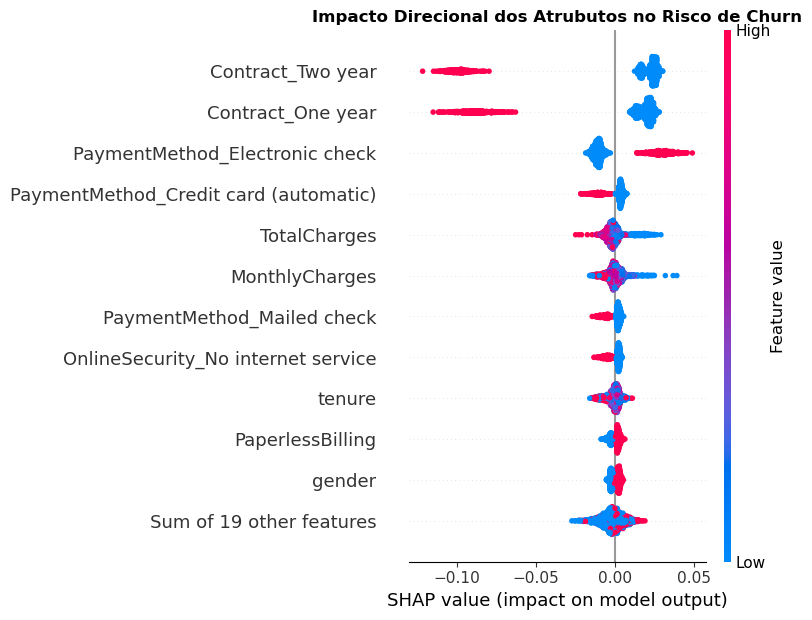

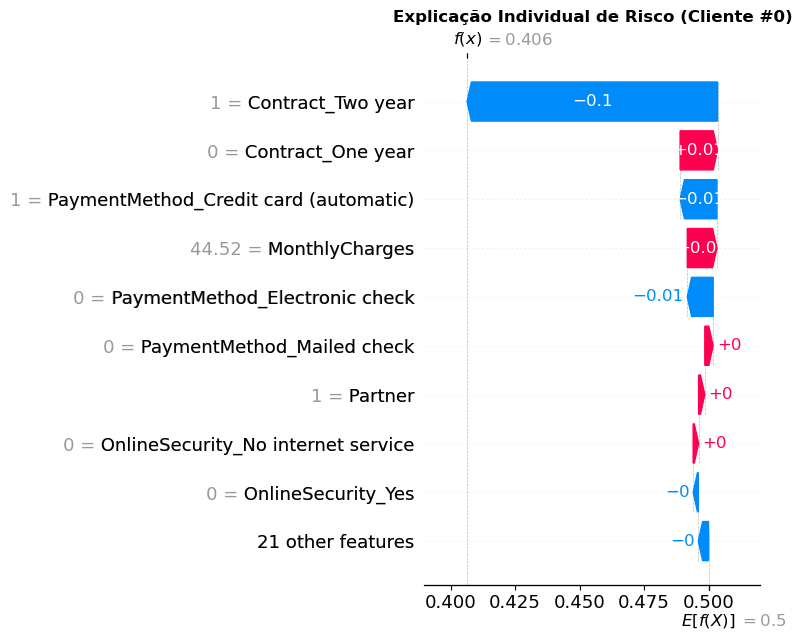

In [9]:
# 1. Carregar os dados de teste
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# carregando o modelo campeão (Random Forest Otimizado)
model = joblib.load('../models/random_forest_tuned.joblib')
print('Modelo Random Forest Otimizado e dados carregados com sucesso!')

# 2. Inicializar o Explainer do SHAP para Árvores (TreeExplainer)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# 3. Gáfico de Importância Global de atributos (SHAP Bar Plot0
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values[:, :, 1], max_display=12, show=False)
plt.title('Importãncia Global das Variáveis do churn (SHAP Bar Plot)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Gráfico de Impacto Direcional (SHAP Beeswarm Plot)
# Mostra se valores altos/baixos da variável aumentam ou diminuem o risco de Churn
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values[:, :, 1], max_display=12, show=False)
plt.title('Impacto Direcional dos Atrubutos no Risco de Churn', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Explicação Local/Individual de um Cliente (Waterfall Plot)
# Analisa a decisão do modelo para o cliente da posição 0
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0, :, 1], max_display=10, show=False)
plt.title('Explicação Individual de Risco (Cliente #0)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#### Análise dos Gráficos
A análise dos três gráficos do SHAP expõe a lógica interna do <b>Random Forest Otimizado</b>, revelando tanto os fatores globais de retenção e risco quanto a justificativa individual para uma previsão específica.

1. <b>Importância Global das Variáveis (SHAP Bar Plot):</b> O gráfico de barras mensura a magnetude média do impacto <b>|SHAP value|</b> de cada atributo na decisão final do modelo:<br>

   *<b>Predomínio dos Tipos de Contrato:</b> As variáveis <b>contract_Two year (+ 0,04</b>) e <b>Contract_One year (+ 0,03)</b> são, isoladamente, os fatores mais influentes para o modelo prever a permanência ou o cancelamento do cliente.<br>
   *<b>Impacto da Forma de Pagamento:</b> O meio de pagamento <b>PaymentMethod_Eletronic check (+0,02)</b> aparece como a terceira variável de maior peso, superando métricas de faturamento direto como <b>TotalCharges</b> e <b>MonthlyCharges</b>.<br>
   *<b>Soma dos Atributos Secundários:</b> As outras 19 variáveis somadas <Sum os 19 other features)</b> acumulam im impacto de +0,02, confirmando que a decisão do modelo está altamente concentrada em poucos variáveis estruturais de contrato e cobrança.

<hr>

2. <b>Impacto Direcional dos atributos (SHAP Beeswarm Plot):</b> O gráfico de dispersão (beeswarm) detalha a direção do impacto (se aumenta ou diminui o risco de Churn) conforme o valor da variável (vrmelho=alto/presente; azul=baixo/ausente):<br>
   
   *<b>Contrato de Longo Prazo (Fatores de Proteção):</b><br>
        * Para <b>contract_Two year</b> e <b>Contract_One year</b>, os pontos vermelhos (clientes que possuem contrato de 1 ou 2 anos) concentram-se fortemente ao lado esquerdo (SHAP < 0). Isso demonstra que ter contrato de longo prazo reduz drasticamente a propabilidade de Churn.<br>

   *<b>Pagamento eletrônico (Vetor de Risco):</b><br>
       * Para <b>PaymentMethod_Eletronic check</b>, os pontos vermelhos (clientes que utilizam pagamento eletrônico) estão posicionados à direita (SHAP >0), provando que esta forma de pagamento é o principal indicador de risco de cancelamento.<br>

   *<b>Cartão de Crédito Automático:</b><br>
       * Os pontos vermelhos em <b>paymentMethod_cred card (automatic)</b> inclinam-se à esquerda (SHAP < 0), confirmando que pagamentos automatizados aumentam a retenção.<br>

<hr>

3. <b>Explicação Individual de Decisão (Waterfall Plot - Cliente#0):</b> O gráfico <i>wateerfall</i> desconstrói a previsão para o Cliente#0, mostrando como o modelo partiu da média geral da base até a probabilidade final:<br>

   *<b>Linha Base (E[f(X)] = 0,5):</b> Probabilidade inicial de referência do modelo para a classe de Churn.<br>
   *<b>Resultado Final (f(x) = 0,406):</b> O modelo claculou um risco de 40,6% de Churn para este cliente (classificando-o como retido/baixo risco).<br>
   *<b>Principais Contribuições:</b><br>
           * <b>Contract_Two year = 1:</b> Foi o maior responsável por reduzir a pontuação do cliente em - 0,10 (de volta em direção a retenção).<br>
           * <b>PaymentMethod_Credir card 9automatic0 = 1</b> e <b>PaymentMethod_Electronic check = 0:</b> Reduzem o risco em -0,01 cada.<br>
           * <b>Contract_One year = 0:</b> Adicionou uma leve pressão positiva (+0.01) para o risco, porém insuficiente para compensar o contrato de 2 anos.<br>

<hr>

#### <b>Recomendações Estratégicas de Negócio:</b><br>

1. <b>Incentivo à Migração de Contratos:</b> Desenvolver campanhas para converter clientes com contrato mês a mês em contratos de 1 ou 2 anos, oferecendo benefícios progressivos.
   
2. <b>Desincentivo ao Pagamento eletrônico:</b> Criar programas de bonificação (ex.; pequenos descontos na fatura) para clientes que migrarem do pagamento eletrônico para débito automático ou cartão de crédito.
